# Modelo de machine learning
Usar:
cross validation

*   Learning curve
*   Cross validation
*   Adversarial Machine Learning




# 0. Configuración de Git y conexión con GitHub

In [ ]:
#Configurar Git
!git config --global user.name "txellbalada"
!git config --global user.email "meritxell.balada@gmail.com"

from google.colab import userdata
# 1. Recuperamos el token de forma segura desde los Secretos de Colab
mi_token = userdata.get('Reto_IA')

# 2. Definimos los datos del repositorio (esto sí puede ser público)
usuario = "txellbalada"
repositorio = "Reto_IA"

# 3. Construimos la URL usando f-strings de Python
repo_url = f"https://{mi_token}@github.com/{usuario}/{repositorio}.git"

# 4. Ejecutamos el comando git clone pasando la variable de Python a Bash usando { }
!git clone {repo_url}

Cloning into 'Reto_IA'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 30 (delta 11), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 6.25 MiB | 10.21 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
%cd Reto_IA

/content/Reto_IA


In [ ]:
# Ver el estado de tus archivos
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!git checkout -b rama-modelo-NN

Switched to a new branch 'rama-modelo-NN'


In [ ]:
!git branch

  main
* rama-modelo-NN


In [ ]:
!git pull origin main

From https://github.com/txellbalada/Reto_IA
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
%ls

500colombiano_dataset_features_real.csv       df_optimizado.csv
500colombiano_dataset_features_sintetico.csv  README.md
500Datos_Reales_colomb.ipynb                  Reto_Telefonica.ipynb
500Datos_Sinteticos_colomb.ipynb


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Cargar CSVs

## Unificación de datasets

In [ ]:
import pandas as pd

# Load the real dataset
df_real = pd.read_csv('500colombiano_dataset_features_real.csv')

# Load the synthetic dataset
df_sintetico = pd.read_csv('500colombiano_dataset_features_sintetico.csv')

# Concatenate the two DataFrames
df_unified = pd.concat([df_real, df_sintetico], ignore_index=True)

df_unified.head()

,id_audio,archivo,label,genero_f,colombiano,chileno,argentino,modelo_cyclegan,modelo_diff,modelo_stargan,...,rolloff_std,rolloff_min,rolloff_max,rolloff_median,rolloff_q1,rolloff_q3,rolloff_skew,rolloff_kurtosis,rolloff_mode,rolloff_iqr
0,1,cof_00610_00008989777.wav,0,1,1,0,0,0,0,0,...,2052.610133,148.4375,7046.8750,4171.87500,2703.125000,5951.171875,-0.464093,-1.007046,187.5000,3248.046875
1,2,cof_00610_00011481761.wav,0,1,1,0,0,0,0,0,...,1802.043666,351.5625,7226.5625,3691.40625,2548.828125,5773.437500,0.028474,-1.184660,1226.5625,3224.609375
2,3,cof_00610_00026180919.wav,0,1,1,0,0,0,0,0,...,2068.538695,148.4375,7195.3125,3437.50000,2603.515625,6167.968750,-0.163310,-1.342991,2734.3750,3564.453125
3,4,cof_00610_00083325222.wav,0,1,1,0,0,0,0,0,...,1927.039568,148.4375,7375.0000,3062.50000,2429.687500,5933.593750,0.229813,-1.189844,2679.6875,3503.906250
4,5,cof_00610_00100787111.wav,0,1,1,0,0,0,0,0,...,1914.970894,312.5000,7414.0625,4539.06250,2552.734375,6128.906250,-0.241595,-1.345283,6039.0625,3576.171875


## Limpieza de features y eliminación adicional de columnas

In [ ]:
def limpiar_dataframe_features(df):
    """
    Toma el DataFrame gigante y elimina las columnas estadísticas redundantes,
    dejando solo mean, std, skew y las métricas base.
    """
    print(f"📊 Tamaño ANTES de limpiar: {df.shape[0]} filas x {df.shape[1]} columnas")

    # 1. Definimos los sufijos de las columnas que NO aportan valor extra
    # y solo generan ruido o colinealidad.
    sufijos_basura = (
        '_min',
        '_max',
        '_median',
        '_q1',
        '_q3',
        '_kurtosis',
        '_mode',
        '_iqr'
    )

    # 2. Buscamos todas las columnas que terminen en esos sufijos
    columnas_a_eliminar = [col for col in df.columns if col.endswith(sufijos_basura)]

    # 3. Hacemos el drop (eliminación) de esas columnas
    df_limpio = df.drop(columns=columnas_a_eliminar)

    print(f"🗑️ Se eliminaron {len(columnas_a_eliminar)} columnas redundantes.")
    print(f"✨ Tamaño DESPUÉS de limpiar: {df_limpio.shape[0]} filas x {df_limpio.shape[1]} columnas")

    return df_limpio


## Inspección del dataset

In [ ]:

df_optimizado = limpiar_dataframe_features(df_unified)

print(df_optimizado.columns.tolist()[:10])

📊 Tamaño ANTES de limpiar: 1000 filas x 588 columnas
🗑️ Se eliminaron 416 columnas redundantes.
✨ Tamaño DESPUÉS de limpiar: 1000 filas x 172 columnas
['id_audio', 'archivo', 'label', 'genero_f', 'colombiano', 'chileno', 'argentino', 'modelo_cyclegan', 'modelo_diff', 'modelo_stargan']


In [ ]:
df_optimizado = df_optimizado.drop(columns=df_optimizado.columns[[0, 1] + list(range(4, 13))])

In [ ]:
df_optimizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 161 entries, label to rolloff_skew
dtypes: float64(159), int64(2)
memory usage: 1.2 MB


In [ ]:
df_optimizado.head()

,label,genero_f,duracion_seg,zcr_mean,zcr_std,zcr_skew,rms_mean,rms_std,rms_skew,rmse_manual,...,contrast_6_skew,contrast_7_mean,contrast_7_std,contrast_7_skew,flatness_mean,flatness_std,flatness_skew,rolloff_mean,rolloff_std,rolloff_skew
0,0,1,4.533313,0.128019,0.108089,1.501966,0.031593,0.042625,1.912293,0.053121,...,0.751345,13.959788,2.039896,0.076575,0.045988,0.069603,1.722626,3987.290933,2052.610133,-0.464093
1,0,1,4.192000,0.136800,0.101736,2.074814,0.041720,0.038599,0.556404,0.057054,...,0.106065,14.549212,2.380859,-0.404010,0.039165,0.064811,1.824671,3881.214489,1802.043666,0.028474
2,0,1,3.370625,0.161128,0.103439,0.495813,0.041737,0.052044,1.277798,0.066926,...,0.733724,14.190494,2.017456,0.294623,0.062014,0.089931,1.314064,3999.852594,2068.538695,-0.163310
3,0,1,5.215937,0.151080,0.096057,0.853542,0.052721,0.045182,0.543208,0.069434,...,0.308042,14.822605,2.233264,0.350862,0.039185,0.069397,2.209749,3804.591641,1927.039568,0.229813
4,0,1,3.381312,0.188730,0.106295,1.295475,0.046090,0.050994,0.662464,0.068849,...,0.778446,14.327559,1.740391,0.325326,0.061669,0.079602,1.190782,4294.442807,1914.970894,-0.241595


## Exportación del dataset optimizado

In [ ]:
from google.colab import files

df_optimizado.to_csv('df_optimizado.csv', index=False)
files.download('df_optimizado.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 2. Cross Validation del modelo XGBoost

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

X = df_optimizado.drop(columns=['label', 'id_audio'], errors='ignore')
y = df_optimizado['label']

modelo_xgb_cv = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision_IA': make_scorer(precision_score, pos_label=1),
    'recall_IA': make_scorer(recall_score, pos_label=1),
    'f1_IA': make_scorer(f1_score, pos_label=1)
}

resultados_cv = cross_validate(
    modelo_xgb_cv,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print("Accuracy promedio:", resultados_cv['test_accuracy'].mean())
print("Desviación:", resultados_cv['test_accuracy'].std())
print("Recall IA:", resultados_cv['test_recall_IA'].mean())

Accuracy promedio: 0.969
Desviación: 0.014966629547095779
Recall IA: 0.9620000000000001


#3. Modelo NN

## XGBoost

In [ ]:
pip install xgboost scikit-learn pandas matplotlib

In [ ]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def entrenar_evaluar_xgboost(df):
    """
    Entrena un modelo XGBoost para detectar deepfakes de audio y evalúa su rendimiento.

    Asume que el DataFrame 'df' tiene:
    - Una columna 'label' (0 = Real, 1 = IA)
    - Una columna 'id_audio' (que no debe usarse para entrenar)
    - El resto de columnas son las features numéricas (mfcc_mean, zcr_std, etc.)
    """
    print("--- Preparando los datos ---")

    # 1. Separar las características (X) de la etiqueta/target (y)
    # Eliminamos 'label' y cualquier columna de identificación como 'id_audio'
    X = df.drop(columns=['label', 'id_audio'], errors='ignore')
    y = df['label']

    # 2. Dividir los datos: 80% para entrenar (aprender) y 20% para test (evaluar)
    # random_state=42 asegura que siempre se divida igual si repites el experimento
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

    print(f"Audios para entrenamiento: {len(X_train)}")
    print(f"Audios para validación: {len(X_test)}")
    print("\n--- Entrenando el modelo XGBoost ---")

    # 3. Configurar e instanciar el modelo
    modelo_xgb = xgb.XGBClassifier(
        n_estimators=100,        # Número de árboles de decisión
        learning_rate=0.1,       # Velocidad de aprendizaje
        max_depth=5,             # Profundidad máxima de cada árbol (evita sobreajuste)
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'    # Métrica interna para evaluar errores
    )

    # 4. Entrenar el modelo con los datos de entrenamiento
    modelo_xgb.fit(X_train, y_train)
    print("✔ Modelo entrenado con éxito.")

    # 5. Hacer predicciones sobre el 20% de datos que el modelo NUNCA ha visto
    predicciones = modelo_xgb.predict(X_test)

    # --- EVALUACIÓN DE RESULTADOS ---
    print("\n--- Resultados de la Evaluación ---")

    precision_global = accuracy_score(y_test, predicciones)
    print(f"Precisión Global (Accuracy): {precision_global * 100:.2f}%\n")

    print("Reporte de Clasificación Detallado:")
    # target_names asume que 0 es Real y 1 es IA
    print(classification_report(y_test, predicciones, target_names=['Real (0)', 'IA (1)']))

    # --- IMPORTANCIA DE LAS CARACTERÍSTICAS (FEATURE IMPORTANCE) ---
    # Esto es vital para explicar en el proyecto de grupo qué miró la IA para decidir
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(modelo_xgb, max_num_features=15, importance_type='weight',
                        title='Top 15 Características Más Importantes',
                        xlabel='Frecuencia de uso en los árboles',
                        ylabel='Características')
    plt.tight_layout()
    plt.show()

    return modelo_xgb



--- Preparando los datos ---
Audios para entrenamiento: 800
Audios para validación: 200

--- Entrenando el modelo XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:26:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✔ Modelo entrenado con éxito.

--- Resultados de la Evaluación ---
Precisión Global (Accuracy): 95.00%

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

    Real (0)       0.95      0.95      0.95       100
      IA (1)       0.95      0.95      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



<Figure size 1000x600 with 0 Axes>

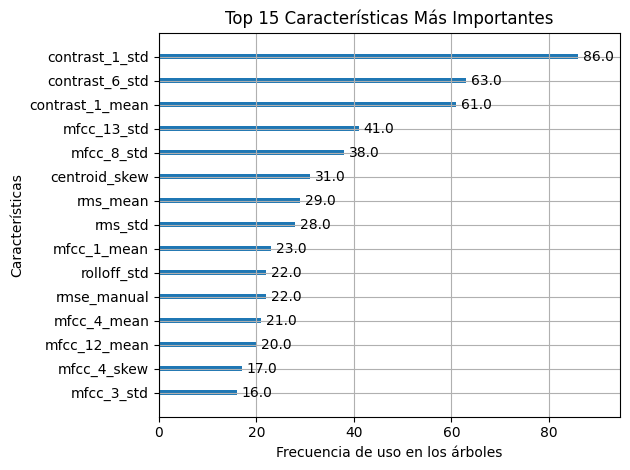

In [ ]:
modelo_entrenado = entrenar_evaluar_xgboost(df_optimizado)

Columnas modelo original: 161
Columnas modelo sin feature: 160
Accuracy modelo SIN contrast_1_std: 0.935

Reporte de clasificación:

              precision    recall  f1-score   support

    Real (0)       0.95      0.92      0.93       100
      IA (1)       0.92      0.95      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200



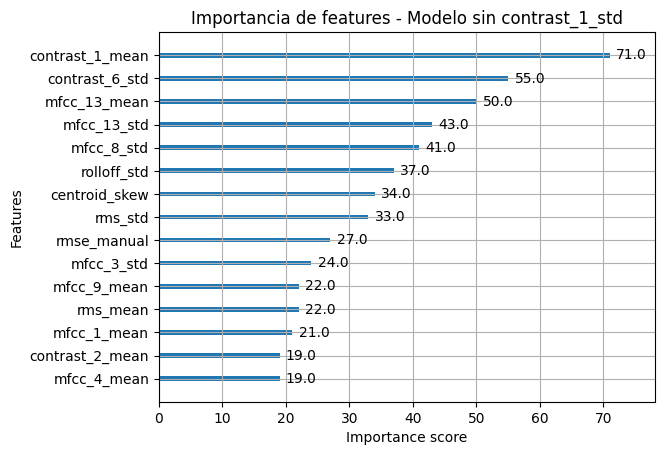

In [ ]:
# ============================================
# 🔬 MODELO ALTERNATIVO SIN FEATURE DOMINANTE
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt

# Copiamos el dataset optimizado para NO tocar el original
df_sin_feature = df_optimizado.copy()

# Feature dominante a eliminar
features_a_eliminar = [
    'contrast_1_std'
]

# Eliminamos la feature solo en este experimento
df_sin_feature = df_sin_feature.drop(
    columns=features_a_eliminar,
    errors='ignore'
)

print("Columnas modelo original:", df_optimizado.shape[1])
print("Columnas modelo sin feature:", df_sin_feature.shape[1])

# Separar X e y
X = df_sin_feature.drop(columns=['label', 'id_audio'], errors='ignore')
y = df_sin_feature['label']

# Split 80/20 igual que el modelo original
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Crear modelo igual al original
modelo_xgb_sin_feature = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Entrenar
modelo_xgb_sin_feature.fit(X_train, y_train)

# Predecir
predicciones_sin_feature = modelo_xgb_sin_feature.predict(X_test)

# Evaluar
accuracy_sin_feature = accuracy_score(y_test, predicciones_sin_feature)

print("Accuracy modelo SIN contrast_1_std:", accuracy_sin_feature)
print("\nReporte de clasificación:\n")
print(classification_report(
    y_test,
    predicciones_sin_feature,
    target_names=['Real (0)', 'IA (1)']
))

# Importancia de features del nuevo modelo
xgb.plot_importance(modelo_xgb_sin_feature, max_num_features=15)
plt.title("Importancia de features - Modelo sin contrast_1_std")
plt.show()

In [ ]:
print("Modelo original: revisar accuracy anterior")
print("Modelo sin contrast_1_std:", accuracy_sin_feature)

Modelo original: revisar accuracy anterior
Modelo sin contrast_1_std: 0.935


# Push final

In [ ]:
%cd /content/Reto_IA

/content/Reto_IA


In [ ]:
!git add .
!git commit -m "Trabajo_28_04"
!git push -u origin rama-modelo-NN

[rama-modelo-NN f85784c] Trabajo_28_04
 1 file changed, 1001 insertions(+), 1001 deletions(-)
 rewrite df_optimizado.csv (69%)
remote: Permission to txellbalada/Reto_IA.git denied to DanyCM97.
fatal: unable to access 'https://github.com/txellbalada/Reto_IA.git/': The requested URL returned error: 403
